# Accident EDA

Two datasets side-by-side:
- **Raw** `data/raw/MOT_accident_data/` — all Thailand, all years combined
- **Clean** `data/processed/accident_bangkok/accidents_clean.gpkg` — Bangkok only, cleaned

In [1]:
import glob
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['font.size']   = 12

RAW_DIR  = "../data/raw/MOT_accident_data"
OSM_DIR  = "../data/raw/osm"
THAI_CRS = "EPSG:32647"

THAILAND_BBOX = dict(lon_min=97.5, lon_max=105.7, lat_min=5.5,  lat_max=20.5)
BANGKOK_BBOX  = dict(lon_min=100.3, lon_max=100.9, lat_min=13.4, lat_max=14.0)

# --- Load raw CSVs (all Thailand) ---
frames = [pd.read_csv(f, encoding='utf-8-sig', low_memory=False)
          for f in sorted(glob.glob(f"{RAW_DIR}/accidents_*.csv"))]
raw = pd.concat(frames, ignore_index=True)
raw['lat']  = pd.to_numeric(raw['LATITUDE'],  errors='coerce')
raw['lon']  = pd.to_numeric(raw['LONGITUDE'], errors='coerce')
raw['year'] = pd.to_numeric(raw['ปีที่เกิดเหตุ'], errors='coerce')
raw['hour'] = pd.to_datetime(raw['เวลา'], format='%H:%M', errors='coerce').dt.hour

# --- Load clean Bangkok GeoDataFrame ---
clean = gpd.read_file("../data/processed/accident_bangkok/accidents_clean.gpkg")

print(f"Raw (all Thailand) : {len(raw):,} rows")
print(f"Clean (Bangkok)    : {len(clean):,} rows | CRS: {clean.crs}")

Raw (all Thailand) : 133,193 rows
Clean (Bangkok)    : 18,734 rows | CRS: EPSG:4326


## 1. Data Quality — Raw vs Clean

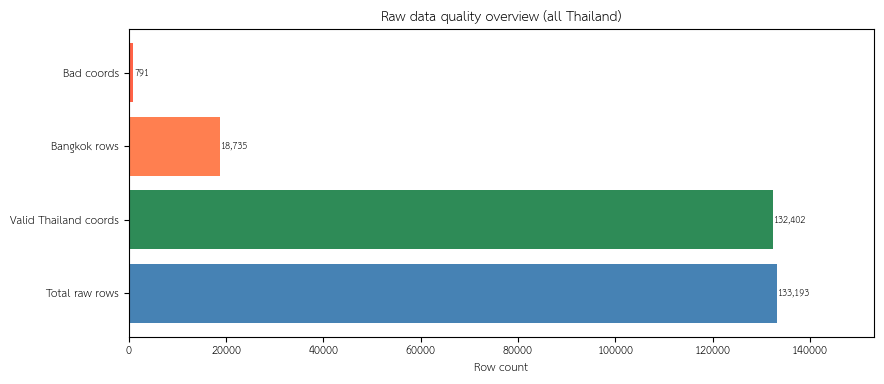

In [2]:
valid_th = (
    raw['lon'].between(THAILAND_BBOX['lon_min'], THAILAND_BBOX['lon_max']) &
    raw['lat'].between(THAILAND_BBOX['lat_min'], THAILAND_BBOX['lat_max'])
)
in_bkk = (
    raw['lon'].between(BANGKOK_BBOX['lon_min'], BANGKOK_BBOX['lon_max']) &
    raw['lat'].between(BANGKOK_BBOX['lat_min'], BANGKOK_BBOX['lat_max'])
)

labels = ['Total raw rows', 'Valid Thailand coords', 'Bangkok rows', 'Bad coords']
values = [len(raw), valid_th.sum(), in_bkk.sum(), (~valid_th).sum()]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values, color=['steelblue', 'seagreen', 'coral', 'tomato'])
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", va='center', fontsize=10)
ax.set_xlabel('Row count')
ax.set_title('Raw data quality overview (all Thailand)')
ax.set_xlim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()

## 2. All-Thailand Spatial Distribution

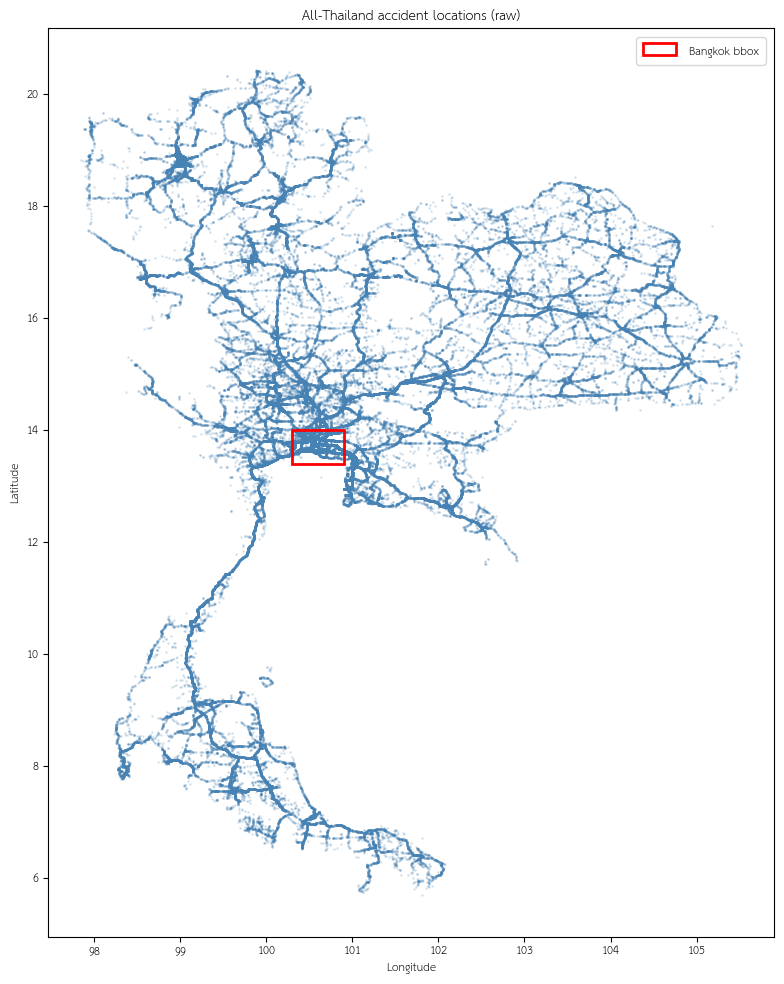

In [3]:
raw_th = raw[valid_th].copy()

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(raw_th['lon'], raw_th['lat'], s=1, alpha=0.15, color='steelblue')
ax.add_patch(Rectangle(
    (BANGKOK_BBOX['lon_min'], BANGKOK_BBOX['lat_min']),
    BANGKOK_BBOX['lon_max'] - BANGKOK_BBOX['lon_min'],
    BANGKOK_BBOX['lat_max'] - BANGKOK_BBOX['lat_min'],
    linewidth=2, edgecolor='red', facecolor='none', label='Bangkok bbox'
))
ax.set_title('All-Thailand accident locations (raw)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

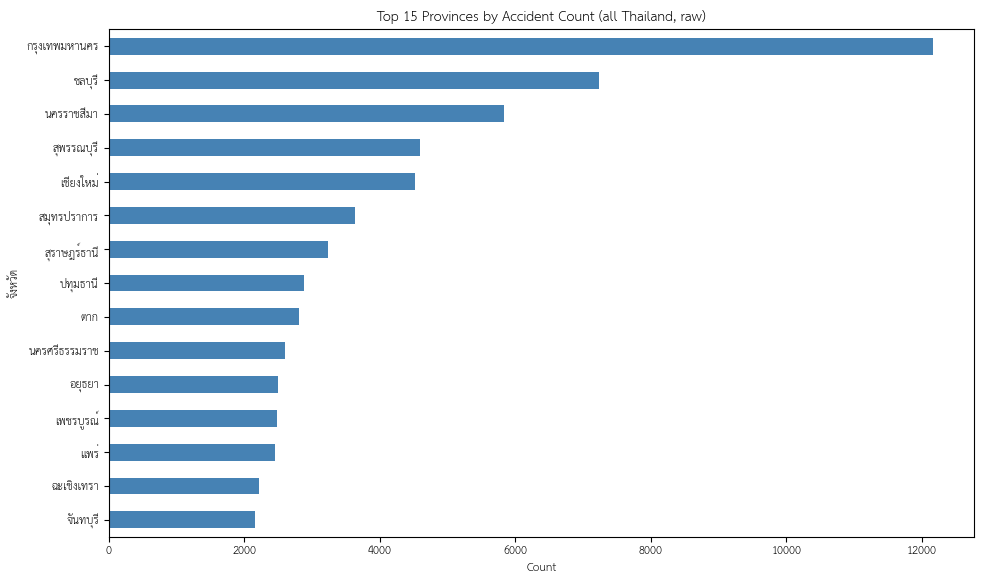

In [4]:
# Top 15 provinces
fig, ax = plt.subplots(figsize=(10, 6))
raw_th['จังหวัด'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=ax, color='steelblue'
)
ax.set_title('Top 15 Provinces by Accident Count (all Thailand, raw)')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 3. Year Trend — All Thailand vs Bangkok

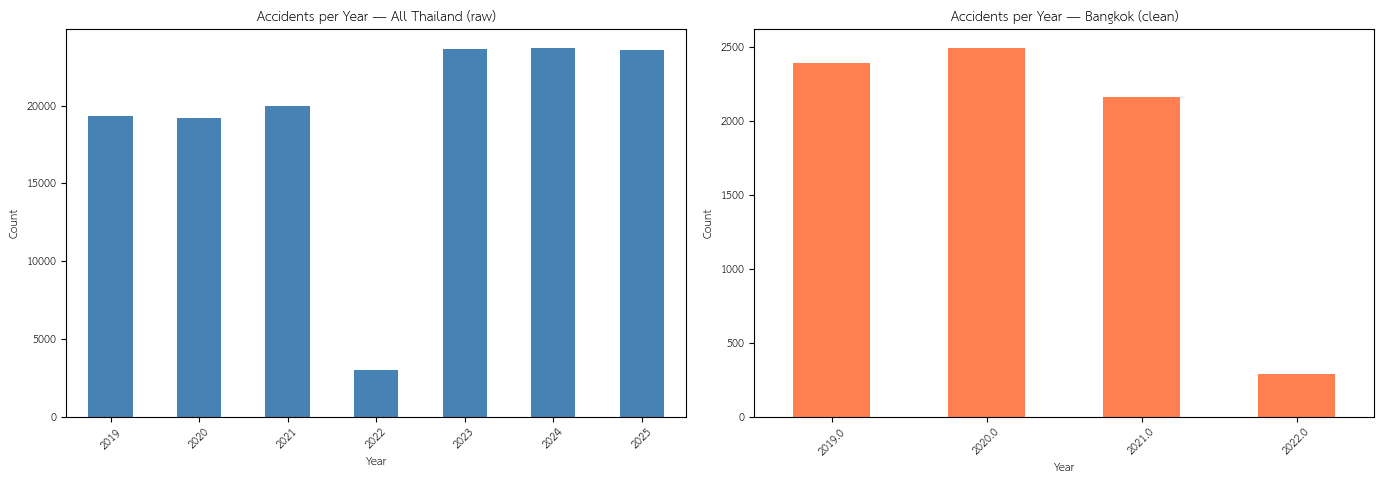

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw_th.groupby('year').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Accidents per Year — All Thailand (raw)')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

clean.groupby('year').size().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Accidents per Year — Bangkok (clean)')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Temporal Patterns — Bangkok Clean File

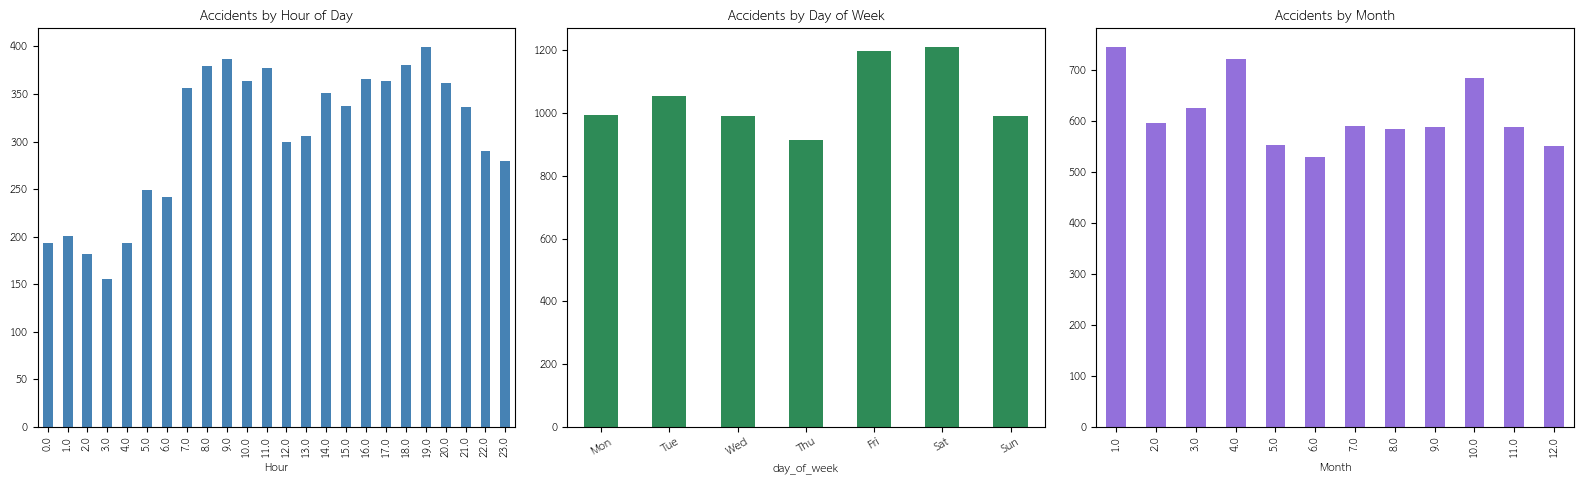

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

clean['hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Accidents by Hour of Day')
axes[0].set_xlabel('Hour')

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
clean['day_of_week'].value_counts().sort_index().rename(
    index=dict(enumerate(dow_labels))
).plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Accidents by Day of Week')
axes[1].tick_params(axis='x', rotation=30)

clean['month'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='mediumpurple')
axes[2].set_title('Accidents by Month')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.show()

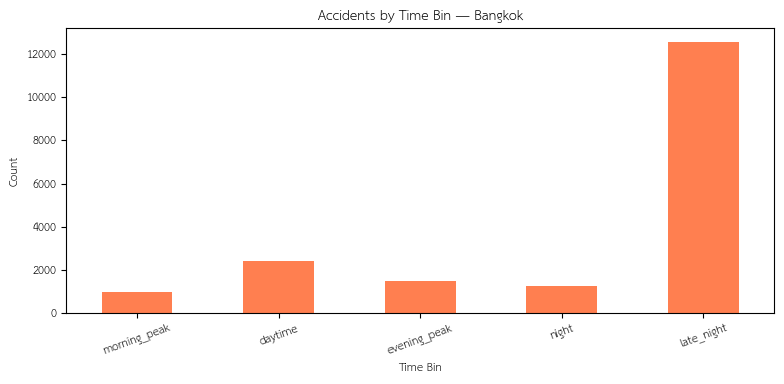

In [7]:
order = ['morning_peak', 'daytime', 'evening_peak', 'night', 'late_night']
fig, ax = plt.subplots(figsize=(8, 4))
clean['time_bin'].value_counts().reindex(order).plot(
    kind='bar', ax=ax, color='coral')
ax.set_title('Accidents by Time Bin — Bangkok')
ax.set_xlabel('Time Bin'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 5. Severity — Bangkok Clean File

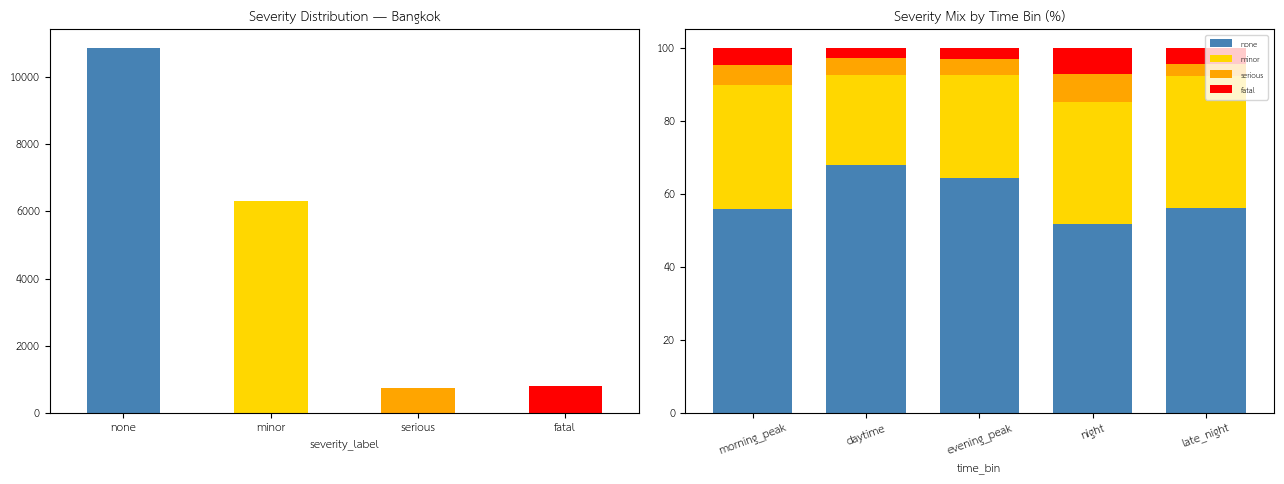

In [8]:
sev_order  = ['none', 'minor', 'serious', 'fatal']
sev_colors = ['steelblue', 'gold', 'orange', 'red']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clean['severity_label'].value_counts().reindex(sev_order).plot(
    kind='bar', ax=axes[0], color=sev_colors)
axes[0].set_title('Severity Distribution — Bangkok')
axes[0].tick_params(axis='x', rotation=0)

sev_time = (
    clean.groupby(['time_bin', 'severity_label'])
    .size().unstack(fill_value=0)
    .reindex(columns=sev_order).reindex(order)
)
sev_time.div(sev_time.sum(axis=1), axis=0).mul(100).plot(
    kind='bar', stacked=True, ax=axes[1], color=sev_colors, width=0.7)
axes[1].set_title('Severity Mix by Time Bin (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Cause & Weather — Bangkok Clean File

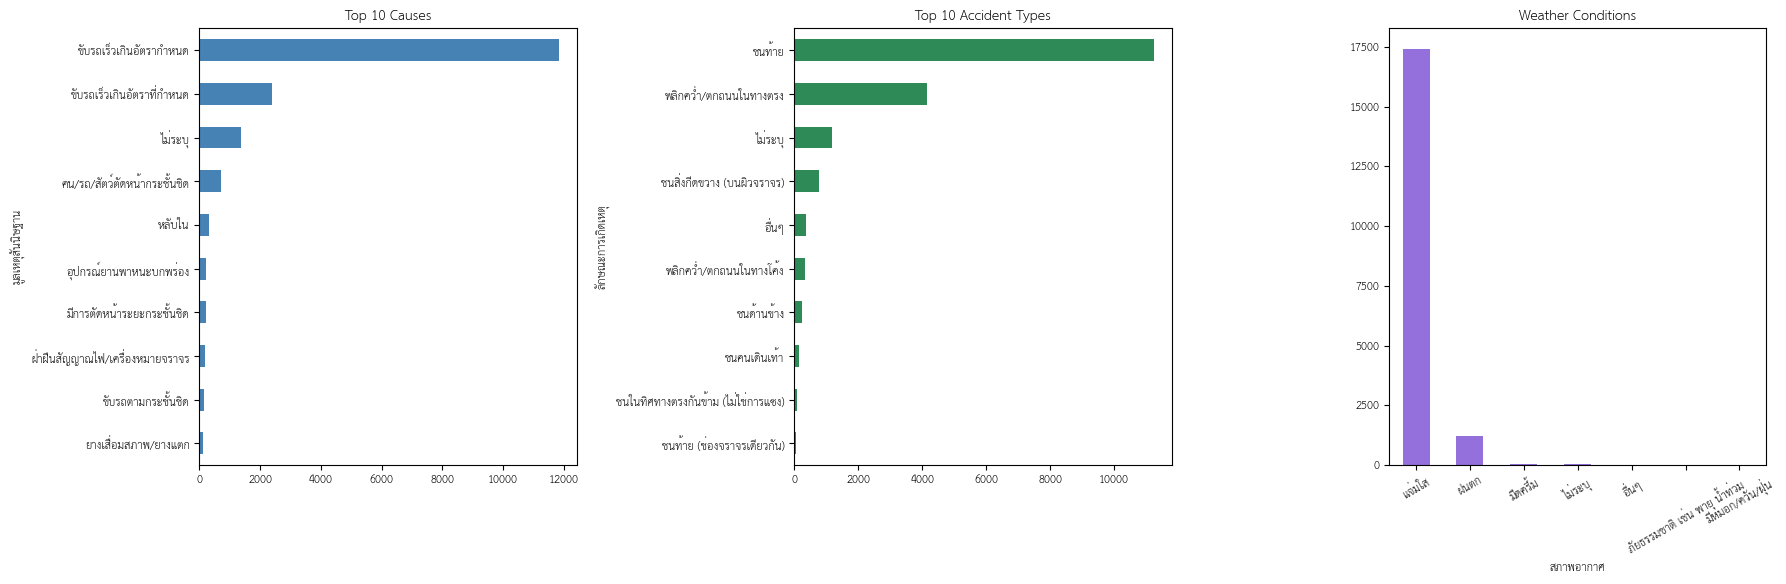

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

clean['มูลเหตุสันนิษฐาน'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Causes')

clean['ลักษณะการเกิดเหตุ'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 10 Accident Types')

clean['สภาพอากาศ'].value_counts().plot(
    kind='bar', ax=axes[2], color='mediumpurple')
axes[2].set_title('Weather Conditions')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Vehicle Types — Bangkok vs All Thailand

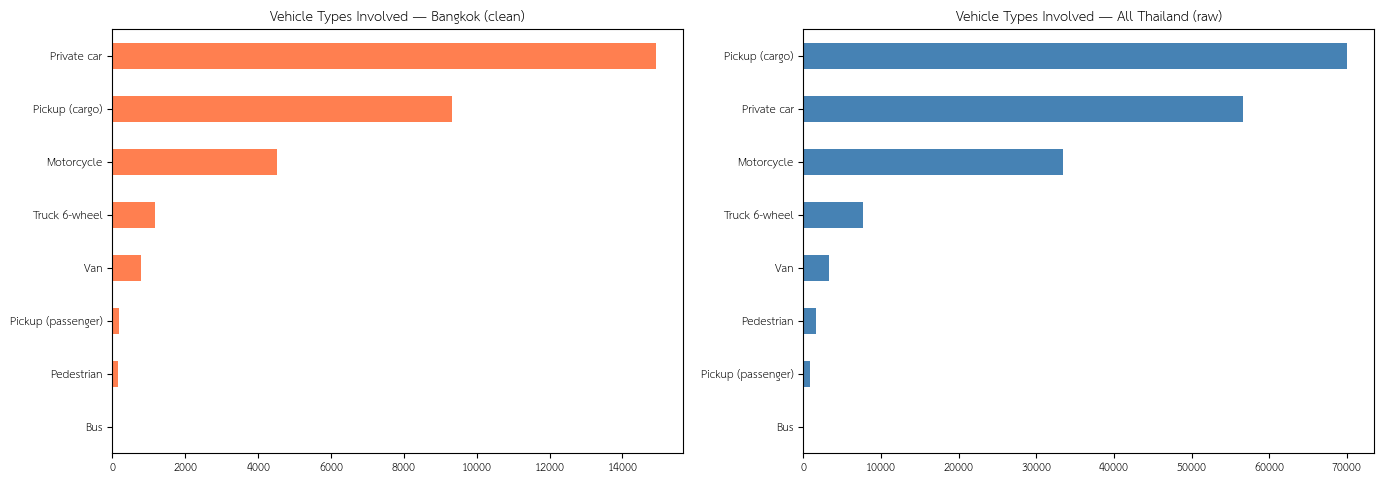

In [10]:
veh_cols = {
    'รถจักรยานยนต์':       'Motorcycle',
    'รถยนต์นั่งส่วนบุคคล': 'Private car',
    'รถตู้':               'Van',
    'รถปิคอัพโดยสาร':      'Pickup (passenger)',
    'รถโดยสารมากกว่า4ล้อ': 'Bus',
    'รถปิคอัพบรรทุก4ล้อ':  'Pickup (cargo)',
    'รถบรรทุก6ล้อ':        'Truck 6-wheel',
    'คนเดินเท้า':          'Pedestrian',
}

bkk_veh = clean[list(veh_cols)].sum().rename(veh_cols)
th_veh  = raw_th[list(veh_cols)].apply(pd.to_numeric, errors='coerce').sum().rename(veh_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bkk_veh.sort_values().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Vehicle Types Involved — Bangkok (clean)')

th_veh.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Vehicle Types Involved — All Thailand (raw)')

plt.tight_layout()
plt.show()

## 8. Spatial Maps — Bangkok Clean File

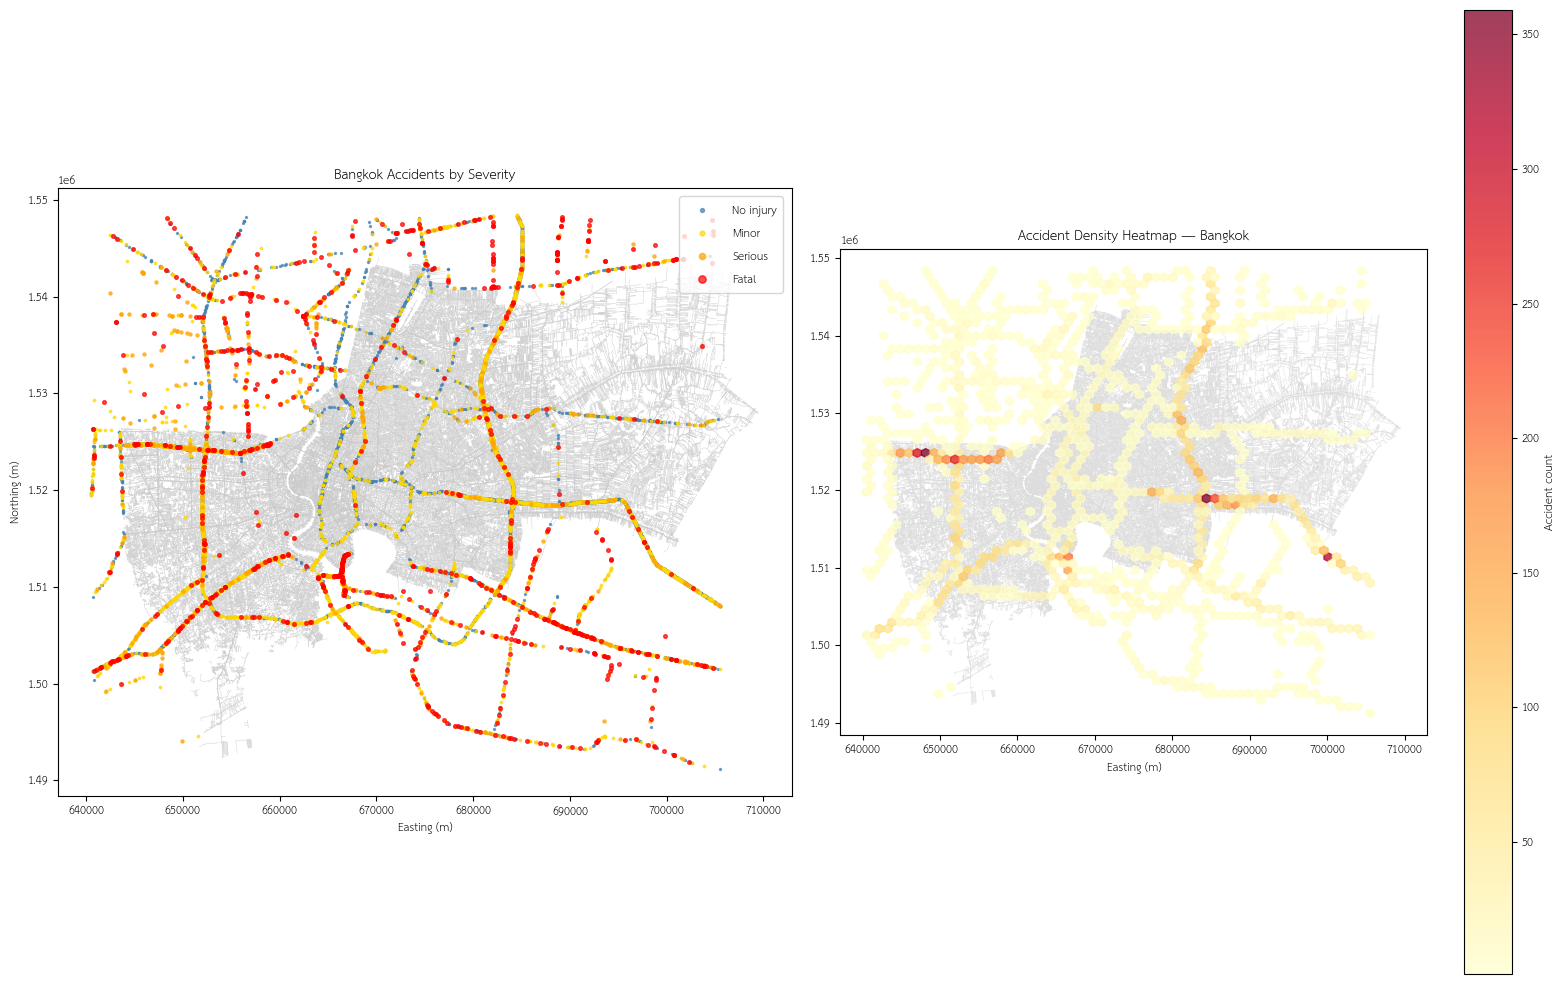

In [11]:
roads     = gpd.read_file(f"{OSM_DIR}/osm_roads.gpkg")
roads_utm = roads[roads.geom_type == 'LineString'].to_crs(THAI_CRS)
clean_utm = clean.to_crs(THAI_CRS)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: severity
roads_utm.plot(ax=axes[0], color='#cccccc', linewidth=0.3, zorder=1)
for sev, color, size, label in [
    (0, 'steelblue', 2, 'No injury'),
    (1, 'gold',      3, 'Minor'),
    (2, 'orange',    5, 'Serious'),
    (3, 'red',       7, 'Fatal'),
]:
    clean_utm[clean_utm['severity'] == sev].plot(
        ax=axes[0], color=color, markersize=size, alpha=0.7, zorder=sev+2, label=label)
axes[0].set_title('Bangkok Accidents by Severity')
axes[0].legend(loc='upper right', markerscale=2)
axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')

# Right: density heatmap
roads_utm.plot(ax=axes[1], color='#dddddd', linewidth=0.3, zorder=1)
hb = axes[1].hexbin(
    clean_utm.geometry.x, clean_utm.geometry.y,
    gridsize=60, cmap='YlOrRd', mincnt=1, alpha=0.75, zorder=2)
plt.colorbar(hb, ax=axes[1], label='Accident count')
axes[1].set_title('Accident Density Heatmap — Bangkok')
axes[1].set_xlabel('Easting (m)')

plt.tight_layout()
plt.show()

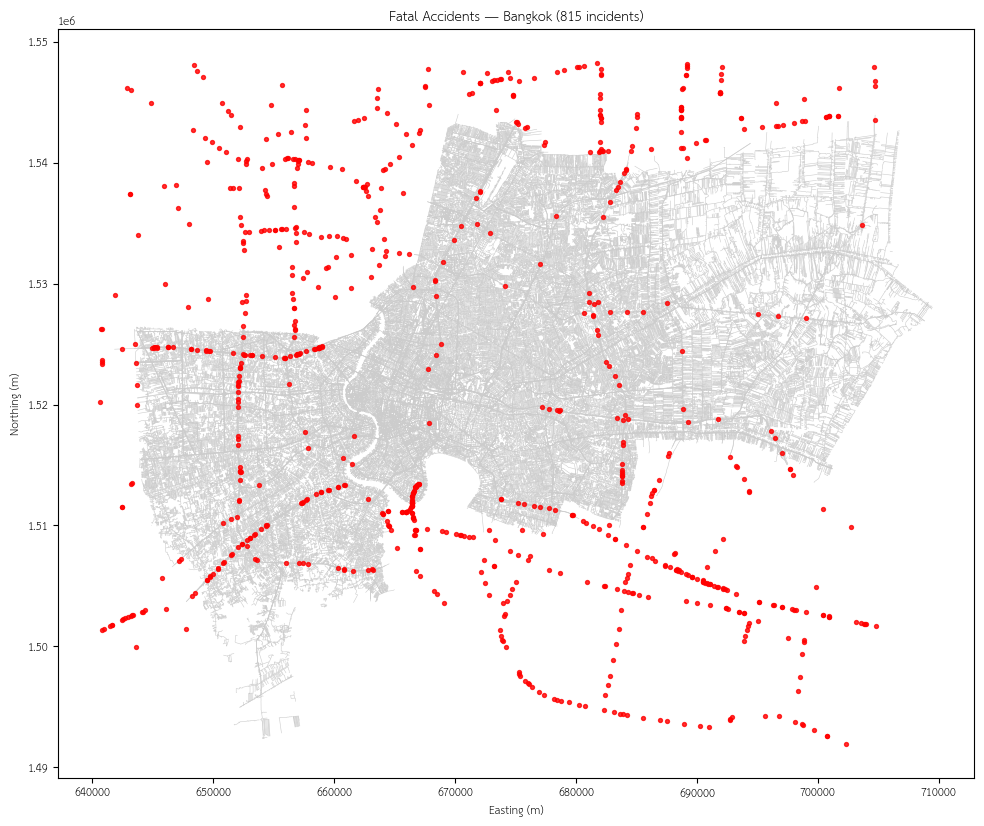

In [12]:
# Fatal accidents only
fatal_utm = clean_utm[clean_utm['severity'] == 3]

fig, ax = plt.subplots(figsize=(10, 10))
roads_utm.plot(ax=ax, color='#cccccc', linewidth=0.4, zorder=1)
fatal_utm.plot(ax=ax, color='red', markersize=8, alpha=0.8, zorder=2)
ax.set_title(f"Fatal Accidents — Bangkok ({len(fatal_utm):,} incidents)")
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

## 9. Heatmap by Hour × Day of Week (Bangkok)

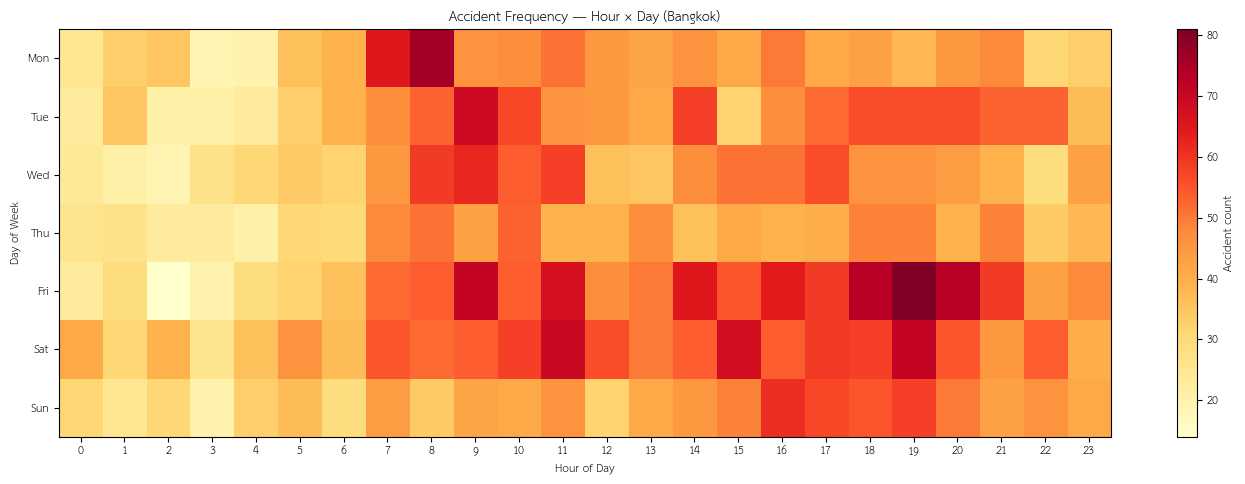

In [13]:
pivot = clean.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Accident count')
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(7));  ax.set_yticklabels(pivot.index)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Day of Week')
ax.set_title('Accident Frequency — Hour × Day (Bangkok)')
plt.tight_layout()
plt.show()

## 10. Key Findings

Fill in after running:

- **Spatial hotspots**: ___
- **Peak hour**: ___
- **Deadliest time bin**: ___
- **Top cause**: ___
- **Dominant vehicle type Bangkok vs Thailand**: ___
- **2022 data gap**: only 291 Bangkok rows — raw download was incomplete